4
[[1 2 2 2 0 2 1]
 [1 1 0 0 2 2 2]]
Complexes per class: [2 2 3 2]
Reactions per class: [1 1 3 1]
Extra conservations 0
Linkage group 1: {0: 'B+E', 1: 'A+G'}
Linkage group 2: {0: 'C+C', 1: 'C+D'}
Linkage group 3: {0: 'D+E', 1: 'A+A', 2: 'F'}
Linkage group 4: {0: 'B+G', 1: 'A+F'}

System of ODEs:


Eq(Derivative(A, t), -2*A**2*k_5 - 2*A**2*k_8 - A*F*k_11 - A*G*k_1 + B*E*k_0 + B*G*k_10 + 2*D*E*k_4 + 2*F*k_9)

Eq(Derivative(B, t), A*F*k_11 + A*G*k_1 - B*E*k_0 - B*G*k_10)

Eq(Derivative(C, t), -C**2*k_2 + C*D*k_3)

Eq(Derivative(D, t), A**2*k_5 + C**2*k_2 - C*D*k_3 - D*E*k_4 - D*E*k_6 + F*k_7)

...

Eq(Derivative(C, t), -C**2*k_2 + C*D*k_3)

Eq(Derivative(D, t), C**2*k_2 - C*D*k_3 - D*E*k_4 - D*E*k_6 + F*k_7 + k_5*(2*C + 2*D - 4*E - 2*F - 3*G - const0 + 2*const1)**2)

Eq(Derivative(E, t), -D*E*k_4 - D*E*k_6 - E*k_0*(-2*C - 2*D + 2*E + G + const0 - const1) + F*k_7 + G*k_1*(2*C + 2*D - 4*E - 2*F - 3*G - const0 + 2*const1) + k_5*(2*C + 2*D - 4*E - 2*F - 3*G - const0 + 2*const1)**2)

Eq(Derivative(F, t), D*E*k_6 - F*k_11*(2*C + 2*D - 4*E - 2*F - 3*G - const0 + 2*const1) - F*k_7 - F*k_9 + G*k_10*(-2*C - 2*D + 2*E + G + const0 - const1) + k_8*(2*C + 2*D - 4*E - 2*F - 3*G - const0 + 2*const1)**2)

Eq(Derivative(G, t), E*k_0*(-2*C - 2*D + 2*E + G + const0 - const1) + F*k_11*(2*C + 2*D - 4*E - 2*F - 3*G - const0 + 2*const1) - G*k_1*(2*C + 2*D - 4*E - 2*F - 3*G - const0 + 2*const1) - G*k_10*(-2*C - 2*D + 2*E + G + const0 - const1))

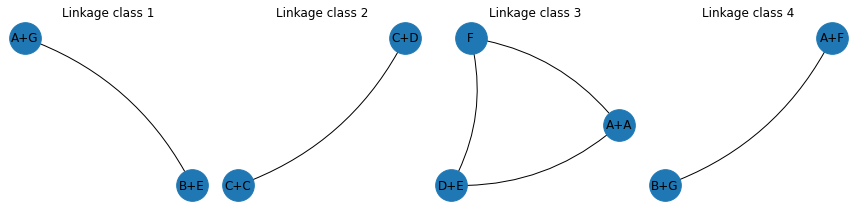

Remaining species after reduction: ['C', 'D', 'E', 'F', 'G']
Conservation constants (symbols): [const0, const1]
Eliminated species solutions: {'A': 2*C + 2*D - 4*E - 2*F - 3*G - const0 + 2*const1, 'B': -2*C - 2*D + 2*E + G + const0 - const1}


In [13]:
from ConservationLaws import *
import numpy as np
import matplotlib.pyplot as plt
import sympy
import networkx as nx

# --- Example usage with new class structure ---

n_species = 7
n_complexes = 9
n_reactions = 6
force_reverse = True
n_cons = 2
n_lcs = n_complexes - n_species + n_cons
print(n_lcs)

# n_species = 6
# n_complexes = 5
# n_reactions = 6
# force_reverse = True
# n_cons = 2
# n_lcs = n_complexes - n_species + n_cons
# print(n_lcs)

seed = 20
np.random.seed(seed)
random.seed(seed)

probs = np.array([6, 6, 6])
probs = probs / sum(probs)
L = random_conservation_laws(n_cons, n_species, probs)
# L = np.array([[0, 0, 1, 1, 1, 1, 0],
#               [1, 2, 1, 0, 0, 0, 1]])
print(L)

# Build the reaction network
r_n = ReactionNetwork(
    n_complexes, n_reactions, n_lcs, n_species, L, n_cons, seed, force_reverse=force_reverse
)

# 1. Create the simulator
sim = ReactionNetworkSimulator(r_n)

print("Complexes per class:", r_n.complexes_per_class)
print("Reactions per class:", r_n.reactions_per_class)
print("Extra conservations", n_species - np.linalg.matrix_rank(r_n.Y @ r_n.A) - n_cons)

for i, node_assignment in enumerate(r_n.assignments):
    print(f"Linkage group {i+1}: {node_assignment}")

# Show symbolic ODEs
symbolic_rhs, species, rates = sim.get_symbolic_rhs()
print("\nSystem of ODEs:")
for i, s in enumerate(species):
    dt_s = sympy.Derivative(s, sympy.symbols('t'))
    display(sympy.Eq(dt_s, symbolic_rhs[i]))

reduced_rhs, remaining_syms, const_syms, rate_syms = sim.get_symbolic_reduced_rhs()
print("\nReduced system of ODEs:")
for i, s in enumerate(remaining_syms):
    dt_s = sympy.Derivative(s, sympy.symbols('t'))
    display(sympy.Eq(dt_s, reduced_rhs[i]))



# Visualize linkage classes
sz = 3
fig, axes = plt.subplots(1, len(r_n.linkage_groups), figsize=(sz*len(r_n.linkage_groups), sz))

if len(r_n.linkage_groups) == 1:
    pos = nx.spring_layout(r_n.linkage_groups[0])
    nx.draw(r_n.linkage_groups[0], pos=pos, with_labels=True, ax=axes, node_size=1000, connectionstyle='arc3,rad=0.2', arrows=True)
    axes.set_title("Linkage class 1")
else:
    for i, (G, ax) in enumerate(zip(r_n.linkage_groups, axes)):
        pos = nx.spring_layout(G)
        nx.draw(G, pos=pos, with_labels=True, ax=ax, node_size=1000, connectionstyle='arc3,rad=0.2', arrows=True)
        ax.set_title(f"Linkage class {i+1}")
plt.tight_layout()
plt.show()

# --- Reduced ODE system and simulation using the Simulator class ---




# 2. Reduce the ODE system using conservation laws
sim.solve_conservation_laws()
print("Remaining species after reduction:", sim.remaining_species)
print("Conservation constants (symbols):", sim.const_syms)
print("Eliminated species solutions:", sim.elimination_solutions)




In [14]:
(dR_dC, dR_dC_func, 
 dR_dl, dR_dl_func, 
 dR_dk, dR_dk_func,
 dR_dC_dk, dR_dC_dk_func, dR_dl_dk, dR_dl_dk_func,
 #dR_dC_dl, dR_dC_dl_func, dR_dl_dl, dR_dl_dl_func,
 remaining_syms) = sim.get_derivatives()
print("\nJacobian of the reduced system:")
display(dR_dC)
print("\nJacobian of the reduced system:")
display(dR_dl)


rates = [r_n.reactions[r_idx][2] for r_idx in range(len(r_n.reactions))]
C_full = generate_initial_concentrations(L, scale=4, offset_scale=3)
print(C_full)
const_vals, C0_reduced = sim.get_const_and_reduced_init(C_full)

args = list(C0_reduced) + list(const_vals) + list(rates)

dR_dC_dk_func(*args).shape

dR_dC_eval = dR_dC_func(*args)
dR_dC_inv_eval = np.linalg.inv(dR_dC_eval)
dR_dl_eval = dR_dl_func(*args)
dR_dC_dk_eval = dR_dC_dk_func(*args)
dR_dl_dk_eval = dR_dl_dk_func(*args)


obj1 = np.tensordot(
    np.tensordot(
        np.tensordot(
            dR_dC_inv_eval, dR_dC_dk_eval, axes = ([1], [0])), 
        dR_dC_inv_eval, axes = ([1], [0])),
    dR_dl_eval, axes = ([2], [0])).swapaxes(-2,-1)

obj2 = np.tensordot(dR_dC_inv_eval, dR_dl_dk_eval, axes = ([1], [0]))

dC_dl_dk = -obj1 + obj2

print(obj1.shape)
print(obj2.shape)



Jacobian of the reduced system:


Matrix([
[                                                                -2*C*k_2 + D*k_3,                                                                                         C*k_3,                                                                                                                                                  0,                                                                                                                                          0,                                                                                                                                           0],
[     2*C*k_2 - D*k_3 + k_5*(8*C + 8*D - 16*E - 8*F - 12*G - 4*const0 + 8*const1),            -C*k_3 - E*k_4 - E*k_6 + k_5*(8*C + 8*D - 16*E - 8*F - 12*G - 4*const0 + 8*const1),                                                                    -D*k_4 - D*k_6 + k_5*(-16*C - 16*D + 32*E + 16*F + 24*G + 8*const0 - 16*const1),                                                          


Jacobian of the reduced system:


Matrix([
[                                                                         0,                                                                              0],
[                  k_5*(-4*C - 4*D + 8*E + 4*F + 6*G + 2*const0 - 4*const1),                      k_5*(8*C + 8*D - 16*E - 8*F - 12*G - 4*const0 + 8*const1)],
[ -E*k_0 - G*k_1 + k_5*(-4*C - 4*D + 8*E + 4*F + 6*G + 2*const0 - 4*const1),    E*k_0 + 2*G*k_1 + k_5*(8*C + 8*D - 16*E - 8*F - 12*G - 4*const0 + 8*const1)],
[F*k_11 + G*k_10 + k_8*(-4*C - 4*D + 8*E + 4*F + 6*G + 2*const0 - 4*const1), -2*F*k_11 - G*k_10 + k_8*(8*C + 8*D - 16*E - 8*F - 12*G - 4*const0 + 8*const1)],
[                                           E*k_0 - F*k_11 + G*k_1 - G*k_10,                                           -E*k_0 + 2*F*k_11 - 2*G*k_1 + G*k_10]])

[-9.08938469  7.59957062  4.80638572  4.201974    6.31433542  5.4429524
  4.98761922]
(5, 2, 12)
(5, 2, 12)


In [17]:
from scipy.integrate import solve_ivp
from functools import partial
import numpy as np
import time

# Set random seed for reproducibility
np.random.seed(42)

rates_copy = [r_n.reactions[r_idx][2] for r_idx in range(len(r_n.reactions))]

# Generate lognormally distributed rate constants
# Using mean=0 and sigma=1 for the underlying normal distribution
n_rates = len(rates)
# rates = np.random.lognormal(mean=0, sigma=7, size=n_rates)
# r_n.update_rates(rates)
# sim = ReactionNetworkSimulator(r_n)

(dR_dC, dR_dC_func, 
 dR_dl, dR_dl_func, 
 dR_dk, dR_dk_func,
 dR_dC_dk, dR_dC_dk_func, dR_dl_dk, dR_dl_dk_func,
#   dR_dC_dl, dR_dC_dl_func, dR_dl_dl, dR_dl_dl_func,
 remaining_syms) = sim.get_derivatives()


st_val = 0
l_init = 1e-3
l_fin = 1e2
l_base = np.array([l_init, l_init])
l_target = np.array([l_fin, l_fin])
l_norm = np.linalg.norm(l_target)
l_unit_vec = l_target / l_norm

# 4. Integrate the reduced system

C_full = generate_positive_initial_concentrations_nnls(L, l_base)
t_span = (0, 10000)
num_points = 200000  
r_tol = 1e-4
a_tol = 1e-4
sol_full, C_full_init = sim.integrate(sim.rhs, C_full, t_span=t_span, num_points=num_points, method='LSODA', rtol=r_tol, atol=a_tol)
const_vals, C0_reduced_initial = sim.get_const_and_reduced_init(C_full_init)

def ode_func(t, C_combined):
    return sim.dC_and_dC_dk_combined_func(t, C_combined, 
                                          rates, l_unit_vec, l_base, 
                                          dR_dC_func, dR_dl_func, 
                                          dR_dC_dk_func, dR_dl_dk_func)


init_combined = np.concatenate([C0_reduced_initial, np.zeros(len(C0_reduced_initial)*len(rates))])


time_start = time.time()
sol = solve_ivp(
    ode_func,
    t_span=(0.0, l_norm),
    y0=init_combined,
    method='LSODA',  # or 'LSODA'
    rtol=r_tol,
    atol=a_tol
)
print("Integration time:", time.time() - time_start)
C_reduced, dC_dk = sim.convert_dC_combined(sol.y[:, -1])

C_full = sim.recover_eliminated_species(l_target + l_base, C_reduced) 

# def ode_func(t, C):
#     return sim.dC_func(
#         t, C,
#         rates,
#         l_target/l_norm,
#         l_base,
#         dR_dC_func,
#         dR_dl_func
#     )

# print(C0_reduced_initial)
# time_start = time.time()
# sol = solve_ivp(
#     ode_func,
#     t_span=(st_val, l_norm),
#     y0=C0_reduced_initial,
#     method='LSODA',  # or 'LSODA'
#     rtol=1e-10,
#     atol=1e-10
# )

# C_full = sim.recover_eliminated_species(l_target + l_base, sol.y[:, -1])

print(C_full)
print(np.dot(L, C_full))


Integration time: 0.07608509063720703
[3.98498505e+00 1.27188626e+01 9.56388243e-13 9.70976825e+00
 6.86114432e-01 1.01962915e+01 3.07661702e+01]
[100.001 100.001]


In [18]:
# 4. Integrate the reduced system
# r_n.update_rates(rates)
# sim = ReactionNetworkSimulator(r_n)

#l_base = np.array([10, 10])
#l_target = np.array([0.0, 900.0])
C_full_init = generate_positive_initial_concentrations_nnls(L, l_base + l_target, min_conc=1e-5)
t_span = (0, 1000)
num_points = 200000  
r_tol = 1e-4
a_tol = 1e-4
time_start = time.time()
sol_full, C_full = sim.integrate(sim.rhs, C_full_init, t_span=t_span, num_points=num_points, method='Radau', rtol=r_tol, atol=a_tol)
print(time.time() - time_start)
print(C_full)
print(np.dot(L, C_full))


# const_vals, C0_reduced_initial = sim.get_const_and_reduced_init(C_full_init)
# sim.make_reduced_rhs_with_conservation(const_vals)
# sol_reduced, C_reduced_final = sim.integrate(sim.reduced_ode_rhs, C0_reduced_initial, t_span=t_span, num_points=num_points, method='Radau', rtol=r_tol, atol=a_tol)
# C_full = sim.recover_eliminated_species(l_target + l_base, C_reduced_final) 
# print(C_reduced_final)
# print(C_full)
# print(np.dot(L, C_full))








0.057727813720703125
[ 3.92373605 11.86329137  1.83595253  8.71460797  0.74114055  9.88371448
 31.48213127]
[100.001 100.001]


In [69]:
import jax
import jax.numpy as jnp

# Prepare initial conditions and rates as JAX arrays
C0 = jnp.array(C_full_init)   # initial concentrations (shape: n_species,)
rates_jax = jnp.array(rates)  # rate constants (shape: n_rates,)

# Integrate the ODE and get final concentrations
final_conc = sim.integrate_final_conc_jax(C0, rates_jax, t0=0.0, t1=100.0, dt0=1e-4, max_steps=int(1e7))
print("Final concentrations:", final_conc)

# Compute the Jacobian (sensitivities) of final concentrations w.r.t. rates
jac = sim.sensitivity_wrt_rates_jax(C0, rates_jax, t0=0.0, t1=100.0, dt0=1e-3, max_steps=int(1e7), mode='rev')
print("dC_final/d rates (JAX autodiff):")
print(jac)
print("Jacobian shape:", jac.shape)  # Should be (n_species, n_rates)

Final concentrations: [ 3.2873023  7.5142035  6.456838   4.869779  85.3191     7.112198 ]
dC_final/d rates (JAX autodiff):
[[ -1.8969461    2.8030744   -0.3989378    0.8278939   -2.149028
    7.844386     1.8595318   -1.9643322 ]
 [  3.7426126   -5.553172     0.78255576  -1.6251198   -4.9082685
   17.913557     4.642818    -4.9043074 ]
 [ -3.7709658    5.5952587    2.5037267   -5.1958575   -4.221956
   15.410243    -4.0375338    4.264857  ]
 [ 12.89974    -19.100842    -0.5907291    1.2259164   -3.1821785
   11.614255     2.7539737   -2.9299905 ]
 [ -7.2871957   10.813177    -1.5141581    3.1422284    9.553447
  -34.870007    -0.59713435   0.6295875 ]
 [  3.5445042   -5.2599497    0.7418918   -1.5392152   -4.6469765
   16.959854    -4.0676775    4.296553  ]]
Jacobian shape: (6, 8)


In [64]:
# # ... existing code ...
# delta = 1e-6  # Small perturbation
# num_rates = len(rates)
# C_full_final = C_full_init  # Assuming last column is final concentrations
# dC_full_drates = np.zeros((len(C_full_final), num_rates))

# for i in range(num_rates):
#     rates_perturbed = rates.copy()
#     rates_perturbed[i] += delta
#     r_n.update_rates(rates_perturbed)
#     sim_perturbed = ReactionNetworkSimulator(r_n)
    
#     sol_perturbed, C_full_perturbed = sim_perturbed.integrate(
#         sim_perturbed.rhs, C_full_init, t_span=t_span, num_points=num_points,
#         method='Radau', rtol=r_tol, atol=a_tol
#     )
#     C_full_perturbed_final = C_full_perturbed
#     dC_full_drates[:, i] = (C_full_perturbed_final - C_full_final) / delta

# print("dC_full/d rates (finite difference):")
# print(dC_full_drates)

In [19]:
# ... existing code ...
delta = 1e-6  # Small perturbation
num_rates = len(rates)

C_full_init = generate_positive_initial_concentrations_nnls(L, l_base + l_target, min_conc=1e0)
#C_full_init = generate_positive_initial_concentrations_nnls(L, l_base, min_conc=1e-6)
#C_full_init = C_full

sol_perturbed, C_full_perturbed = sim.integrate(
        sim.rhs, C_full_init, t_span=t_span, num_points=num_points,
        method='LSODA', rtol=r_tol, atol=a_tol
    )
    
const_vals, C0_reduced_final = sim.get_const_and_reduced_init(C_full_perturbed)
print(C0_reduced_final)
dC_reduced_drates = np.zeros((len(C0_reduced_final), num_rates))

t_span = (0, 10000)
num_points = 200000  
r_tol = 1e-10
a_tol = 1e-10

for i in range(num_rates):
 
    # Central difference: f'(x) ≈ (f(x+δ) - f(x-δ)) / (2δ)
    rates_perturbed = rates.copy()
    rates_perturbed[i] += delta
    r_n.update_rates(rates_perturbed)
    sim_perturbed_plus = ReactionNetworkSimulator(r_n)
    reduced_rhs, remaining_syms, const_syms, rate_syms = sim_perturbed_plus.get_symbolic_reduced_rhs()
    sol_perturbed_plus, C_full_perturbed_plus = sim_perturbed_plus.integrate(
        sim_perturbed_plus.rhs, C_full_init, t_span=t_span, num_points=num_points,
        method='LSODA', rtol=r_tol, atol=a_tol
    )
    const_vals_perturbed_plus, C0_reduced_perturbed_final_plus = sim_perturbed_plus.get_const_and_reduced_init(C_full_perturbed_plus)

    rates_perturbed = rates.copy()
    rates_perturbed[i] -= delta
    r_n.update_rates(rates_perturbed)
    sim_perturbed_minus = ReactionNetworkSimulator(r_n)
    reduced_rhs, remaining_syms, const_syms, rate_syms = sim_perturbed_minus.get_symbolic_reduced_rhs()
    sol_perturbed_minus, C_full_perturbed_minus = sim_perturbed_minus.integrate(
        sim_perturbed_minus.rhs, C_full_init, t_span=t_span, num_points=num_points,
        method='LSODA', rtol=r_tol, atol=a_tol
    )
    const_vals_perturbed_minus, C0_reduced_perturbed_final_minus = sim_perturbed_minus.get_const_and_reduced_init(C_full_perturbed_minus)

    dC_reduced_drates[:, i] = (C0_reduced_perturbed_final_plus - C0_reduced_perturbed_final_minus) / (2 * delta)

print("dC_full/d rates (finite difference):")
print(dC_reduced_drates)

[ 1.83595258  8.71460795  0.74114055  9.88371447 31.48213129]
dC_full/d rates (finite difference):
[[  0.37570795  -5.27849269  -1.08007582   5.1267359   -0.23931322
    0.57045014  -0.1951618    0.29865189   0.10524539  -0.06756432
    0.37952217  -0.03940477]
 [  1.78335079 -25.05511026   0.57656499  -2.73672978  -1.13593395
    2.70772208  -0.92636303   1.41759333   0.4995621   -0.32070359
    1.80145555  -0.18704031]
 [ -0.2149686    3.02018805  -0.03464289   0.1644383   -0.05707979
    0.13606068  -0.11417404   0.17471912  -0.13609634   0.08737075
    1.82172227  -0.18916242]
 [ -0.84418591  11.86030023   0.19192266  -0.91095624   0.11185482
   -0.26663246   0.83397995  -1.2762232    1.72132519  -1.10505151
   26.33728353  -2.73476802]
 [  2.34465428 -32.94091509  -0.43011846   2.04168786  -1.03417323
    2.46514355  -1.09672096   1.6783081   -0.14911864   0.09573091
  -20.27578343   2.10536187]]


In [20]:
time_start = time.time()
print(sim.dC_dk_func(C0_reduced_final, const_vals, rates, dR_dC_func, dR_dk_func))
print(time.time() - time_start)

[[  0.37570907  -5.27849133  -1.08007673   5.12673658  -0.23931345
    0.57045087  -0.19516186   0.29865288   0.10524404  -0.06756443
    0.37951978  -0.03940806]
 [  1.78335609 -25.05510383   0.57656067  -2.73672655  -1.13593505
    2.70772553  -0.9263633    1.41759802   0.49955567  -0.3207041
    1.80144418  -0.18705592]
 [ -0.21496898   3.02018768  -0.03464297   0.16443774  -0.05707961
    0.13606053  -0.11417402   0.17471857  -0.1360958    0.0873706
    1.82172284  -0.18916159]
 [ -0.844185    11.86030264   0.19191677  -0.91096      0.11185587
   -0.26663055   0.83397985  -1.2762252    1.72132511  -1.10505406
   26.33727832  -2.73477465]
 [  2.34464758 -32.94091907  -0.43012943   2.04167003  -1.03416789
    2.46514339  -1.09672083   1.67829326  -0.14910728   0.0957237
  -20.27577949   2.10536894]]
0.0007970333099365234


In [71]:
test_ind = 0
# Calculate angle between vectors using dot product formula: cos(theta) = (a·b)/(|a||b|)
print(dC_reduced_drates[test_ind])
print(dC_dk[test_ind])
v1 = dC_reduced_drates[test_ind]
v2 = dC_dk[test_ind]
dot_product = np.dot(v1, v2)
norms = np.linalg.norm(v1) * np.linalg.norm(v2)
angle = np.arccos(np.clip(dot_product/norms, -1.0, 1.0))
print(f"Angle between vectors (radians): {angle}")

[-3.74928351  5.5513532   2.50397053 -5.19636229 -4.22214221 15.41167078
 -4.03798018  4.26517327]
[-8.46101571 12.52774246  4.80627122 -9.97421214 -7.17355223 26.1849084
 -8.15182122  8.61047806]
Angle between vectors (radians): 0.10687840484311478


In [72]:
display(sympy.Matrix(dC_reduced_drates))
display(sympy.Matrix(dC_dk))
display(sympy.Matrix(dC_reduced_drates/ dC_dk))


Matrix([
[-3.74928350987958,  5.55135320245981,   2.50397052736773, -5.19636228801801, -4.22214220963113,  15.4116707795637,  -4.03798017512003,   4.2651732687915],
[ 12.9003362410174, -19.1007881480409, -0.590740577788296,  1.22593516360681, -3.18189221593101,  11.6145484554409,    2.7532517146156, -2.90816250636539],
[-7.24273791519181,  10.7239145208382,   -1.5142537392876,  3.14245735211216,  9.55302618876885, -34.8704620520834, -0.574765067540284, 0.607101341643101],
[ 3.52227953559492, -5.21524119756478,  0.736410104451579, -1.52823601906604, -4.64581622283688,  16.9581611850766,  -4.06783848116987,  4.29671383583852]])

Matrix([
[-8.46101570881565,  12.5277424556817,  4.80627121885853, -9.97421213591824, -7.17355223140806,  26.1849083973542,  -8.15182122201218, 8.61047806311934],
[ 25.0731583422099,  -37.124392752806,  -1.3331317945453,  2.76658114335258, -5.40613560057381,  19.7334822300325,   5.44849134075249, -5.7550471102045],
[  -12.30563912533,  18.2202566476825, -2.57276556158408,  5.33913054813394,  16.2308958010772, -59.2460340495472, -0.976546631523443,  1.0314913832556],
[ 5.98448564196995, -8.86088590690241,  1.25118892076242, -2.59652923223064, -7.89338963470678,  28.8124596938848,  -8.21919183070696, 8.68163923464981]])

Matrix([
[0.443124518250586, 0.443124786616451, 0.520979864295384,  0.52097972423359, 0.588570637451452, 0.588570734932225, 0.495346998559826, 0.495346859666273],
[0.514507828050527, 0.514507759769276, 0.443122413106788, 0.443122793109622, 0.588570552243137, 0.588570649622327, 0.505323683644755, 0.505323840218233],
[0.588570641591732, 0.588570991517959, 0.588570432494149, 0.588570989935893, 0.588570483468624, 0.588570401571883, 0.588568993007156, 0.588566566331329],
[0.588568466250922, 0.588568823970776, 0.588568274727724, 0.588568770994793, 0.588570492252087, 0.588570408956646, 0.494919520672628, 0.494919648203031]])

In [45]:
jac[3]

Array([ 75.01453  ,  -6.1300635, -33.537086 ,  10.152399 ,  -8.837993 ,
         7.0790944, -10.637771 ,   5.975672 ], dtype=float32)

In [12]:
def dC_dl_dk_func_ext(t, C, rates, l_unit_vec, l_base, dR_dC_func, dR_dl_func, dR_dC_dk_func, dR_dl_dk_func):
    const_vals = l_unit_vec * t + l_base
    args = list(C) + list(const_vals) + list(rates)

    dR_dC_eval = dR_dC_func(*args)
    M = np.linalg.inv(dR_dC_eval)
    dR_dl_eval = dR_dl_func(*args)
    dR_dC_dk_eval = dR_dC_dk_func(*args)
    dR_dl_dk_eval = dR_dl_dk_func(*args)

    term_1 = np.tensordot(
        np.tensordot(
            np.tensordot(
                M, dR_dC_dk_eval, axes = ([1], [0])), 
            M, axes = ([1], [0])),
        dR_dl_eval, axes = ([2], [0])).swapaxes(-2,-1)

    term_2 = np.tensordot(M, dR_dl_dk_eval, axes = ([1], [0]))

    dC_dl_dk = term_1 + term_2
    return dC_dl_dk

In [95]:
min_conc = 1e-3
t = 1
l_unit_vec = np.array([0.4, 0.2])/np.linalg.norm(np.array([0.4, 0.2]))
l_base = np.array([10.0, 10.0])
const_vals = l_unit_vec * t + l_base

t_span = (0, 1000)
num_points = 2000  
r_tol = 1e-10
a_tol = 1e-10
r_n.update_rates(rates_copy)
sim = ReactionNetworkSimulator(r_n)
reduced_rhs, remaining_syms, const_syms, rate_syms = sim.get_symbolic_reduced_rhs()
C_full_init = generate_positive_initial_concentrations_nnls(L, const_vals, min_conc=min_conc)
sol, C_full_init_fin = sim.integrate(
    sim.rhs, C_full_init, t_span=t_span, num_points=num_points,
    method='LSODA', rtol=r_tol, atol=a_tol
)

const_vals, C0_reduced_final = sim.get_const_and_reduced_init(C_full_init_fin)
print(const_vals)

dc_an = sim.dC_dl_dk_func(t, C0_reduced_final, 
                    rates_copy, l_unit_vec, l_base, 
                    dR_dC_func, dR_dl_func, 
                    dR_dC_dk_func, dR_dl_dk_func)

sol_perturbed, C_full_init = sim.integrate(
        sim.rhs, C_full_init, t_span=t_span, num_points=num_points,
        method='LSODA', rtol=r_tol, atol=a_tol
    )

dC_reduced_drates = np.zeros((len(C0_reduced_final), num_rates))

t_span = (0, 100)
num_points = 20000  
r_tol = 1e-10
a_tol = 1e-10

# --- Compute d^2C/dl dk using finite differences ---
epsilon = 1e-3  # Small perturbation for l (const_vals)
delta = epsilon
num_l = len(const_vals)
d2C_dldk = np.zeros((len(C0_reduced_final), num_l, num_rates))

for i in range(num_rates):
    for j in range(num_l):
        # Prepare perturbed const_vals
        const_vals_plus = const_vals.copy()
        const_vals_plus[j] += epsilon
        const_vals_minus = const_vals.copy()
        const_vals_minus[j] -= epsilon

        # k_i + delta, l_j + epsilon
        rates_perturbed = rates.copy()
        rates_perturbed[i] += delta
        r_n.update_rates(rates_perturbed)
        sim_pp = ReactionNetworkSimulator(r_n)
        C_full_init_pp = generate_positive_initial_concentrations_nnls(L, const_vals_plus, min_conc=min_conc)
        reduced_rhs, remaining_syms, const_syms, rate_syms = sim_pp.get_symbolic_reduced_rhs()
        sol_pp, C_full_pp = sim_pp.integrate(
            sim_pp.rhs, C_full_init_pp, t_span=t_span, num_points=num_points,
            method='LSODA', rtol=r_tol, atol=a_tol
        )
        _, C0_reduced_pp = sim_pp.get_const_and_reduced_init(C_full_pp)

        # k_i - delta, l_j + epsilon
        rates_perturbed = rates.copy()
        rates_perturbed[i] -= delta
        r_n.update_rates(rates_perturbed)
        sim_pm = ReactionNetworkSimulator(r_n)
        C_full_init_pm = generate_positive_initial_concentrations_nnls(L, const_vals_plus, min_conc=min_conc)
        reduced_rhs, remaining_syms, const_syms, rate_syms = sim_pm.get_symbolic_reduced_rhs()
        sol_pm, C_full_pm = sim_pm.integrate(
            sim_pm.rhs, C_full_init_pm, t_span=t_span, num_points=num_points,
            method='LSODA', rtol=r_tol, atol=a_tol
        )
        _, C0_reduced_pm = sim_pm.get_const_and_reduced_init(C_full_pm)

        # k_i + delta, l_j - epsilon
        rates_perturbed = rates.copy()
        rates_perturbed[i] += delta
        r_n.update_rates(rates_perturbed)
        sim_mp = ReactionNetworkSimulator(r_n)
        C_full_init_mp = generate_positive_initial_concentrations_nnls(L, const_vals_minus, min_conc=min_conc)
        reduced_rhs, remaining_syms, const_syms, rate_syms = sim_mp.get_symbolic_reduced_rhs()
        sol_mp, C_full_mp = sim_mp.integrate(
            sim_mp.rhs, C_full_init_mp, t_span=t_span, num_points=num_points,
            method='LSODA', rtol=r_tol, atol=a_tol
        )
        _, C0_reduced_mp = sim_mp.get_const_and_reduced_init(C_full_mp)

        # k_i - delta, l_j - epsilon
        rates_perturbed = rates.copy()
        rates_perturbed[i] -= delta
        r_n.update_rates(rates_perturbed)
        sim_mm = ReactionNetworkSimulator(r_n)
        C_full_init_mm = generate_positive_initial_concentrations_nnls(L, const_vals_minus, min_conc=min_conc)
        reduced_rhs, remaining_syms, const_syms, rate_syms = sim_mm.get_symbolic_reduced_rhs()
        sol_mm, C_full_mm = sim_mm.integrate(
            sim_mm.rhs, C_full_init_mm, t_span=t_span, num_points=num_points,
            method='LSODA', rtol=r_tol, atol=a_tol
        )
        _, C0_reduced_mm = sim_mm.get_const_and_reduced_init(C_full_mm)

        # Central difference formula for mixed partials
        d2C_dldk[:, j, i] = (
            C0_reduced_pp - C0_reduced_pm - C0_reduced_mp + C0_reduced_mm
        ) / (4 * epsilon * delta)

print("d^2C/dl dk (finite difference):")
print(d2C_dldk)



[10.89442719 10.4472136 ]
d^2C/dl dk (finite difference):
[[[-0.28235243  0.41807036  0.08456161 -0.17548469 -0.02795138
    0.10204258 -0.18576296  0.19621919]
  [ 0.22346705 -0.330869   -0.04398623  0.09128283 -0.04182875
    0.15266649  0.12092519 -0.12772936]]

 [[ 0.47402302 -0.70186475 -0.04449094  0.09232568 -0.02107489
    0.07689462  0.11314298 -0.11951867]
  [-0.2654611   0.39303579  0.03521228 -0.07306436 -0.03151715
    0.11508747 -0.06877686  0.07264738]]

 [[-0.04795379  0.07100418 -0.0100241   0.020805    0.06325499
   -0.23087364 -0.00380028  0.00402002]
  [-0.07174321  0.10623963 -0.0150026   0.03112953  0.09463551
   -0.34546561 -0.00569576  0.00601577]]

 [[ 0.02331727 -0.03453065  0.00487554 -0.01011821 -0.03076028
    0.11227934  0.1092987  -0.11544907]
  [ 0.0348931  -0.05166624  0.00729233 -0.01513946 -0.04602463
    0.16800057 -0.17460837  0.18443263]]]


In [96]:
dc_an

array([[[-0.07139532,  0.10571096,  0.03795951, -0.07877545,
         -0.05329194,  0.19452631, -0.06583239,  0.06953641],
        [-0.07969332,  0.11799735,  0.0423714 , -0.08793122,
         -0.05948586,  0.21713536, -0.07348384,  0.07761836]],

       [[ 0.19915218, -0.29487325, -0.01124911,  0.02334472,
         -0.04016189,  0.14659898,  0.04362414, -0.04607862],
        [ 0.22229887, -0.32914524, -0.01255656,  0.02605799,
         -0.04482975,  0.16363762,  0.04869441, -0.05143416]],

       [[-0.09141794,  0.13535732, -0.01911294,  0.03966412,
          0.12057847, -0.44013565, -0.00725472,  0.0076629 ],
        [-0.1020431 ,  0.15108939, -0.02133436,  0.04427413,
          0.13459284, -0.49129093, -0.0080979 ,  0.00855353]],

       [[ 0.04445826, -0.06582681,  0.00929498, -0.01928941,
         -0.05863957,  0.21404624, -0.05911962,  0.06244595],
        [ 0.04962548, -0.07347761,  0.0103753 , -0.02153134,
         -0.06545503,  0.23892402, -0.06599087,  0.06970381]]])

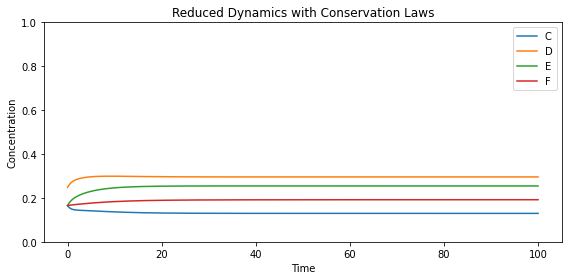

In [75]:
plt.figure(figsize=(8, 4))
for i, name in enumerate(sim.remaining_species):
    plt.plot(sol_mm.t, sol_mm.y[i], label=name)
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.legend()
plt.ylim(0, 1)
plt.title('Reduced Dynamics with Conservation Laws')
plt.tight_layout()
plt.show()

In [61]:
rate_syms

[k_0, k_1, k_2, k_3, k_4, k_5, k_6, k_7]

In [ ]:
def get_derivatives_ext(sim):
    """
    Returns symbolic and lambdified derivatives of the reduced ODE system with respect to remaining species, conservation constants, and rate constants.
    
    Tensor and function naming/indexing convention:
        dX_dY_dZ[i, j, k] = ∂²X_i / ∂Y_j ∂Z_k
    where X is the numerator (e.g., R), Y and Z are the denominator variables (e.g., C, l, k), and indices follow this order.
    All lambdified functions return arrays with the same indexing convention.
    
    Returns:
        dR_dC, dR_dC_func: Jacobian w.r.t. remaining species
        dR_dl, dR_dl_func: Jacobian w.r.t. conservation constants
        dR_dC_dk, dR_dC_dk_func: 2nd derivative w.r.t. species and rate constants
        dR_dl_dk, dR_dl_dk_func: 2nd derivative w.r.t. conservation constants and rate constants
        dR_dC_dl, dR_dC_dl_func: 2nd derivative w.r.t. species and conservation constants
        dR_dl_dl, dR_dl_dl_func: 2nd derivative w.r.t. conservation constants (twice)
        remaining_syms: list of sympy symbols for the remaining species
    """
    reduced_rhs, remaining_syms, const_syms, rate_syms = sim.get_symbolic_reduced_rhs()
    print(reduced_rhs)
    print(remaining_syms)
    print(const_syms)
    print(rate_syms)
    
    arg_syms = list(remaining_syms) + list(const_syms) + list(rate_syms)

    dR_dC = sympy.Matrix(reduced_rhs).jacobian(remaining_syms)
    dR_dC_func = sympy.lambdify(
        arg_syms,
        dR_dC,
        modules='numpy'
    )

    dR_dl = sympy.Matrix(reduced_rhs).jacobian(const_syms)
    dR_dl_func = sympy.lambdify(
        arg_syms,
        dR_dl,
        modules='numpy'
    )

    dR_dk = sympy.Matrix(reduced_rhs).jacobian(rate_syms)
    dR_dk_func = sympy.lambdify(
        arg_syms,
        dR_dk,
        modules='numpy'
    )

    # dR_dC_dk: (m, n, p)
    m, n = dR_dC.shape
    p = len(rate_syms)
    dR_dC_dk = sympy.MutableDenseNDimArray(
        [[[dR_dC[i, j].diff(rate_syms[k]) for k in range(p)] for j in range(n)] for i in range(m)]
    )
    print(dR_dC_dk[2,3])
    # Lambdify each entry individually, then wrap in a function that evaluates the whole tensor
    def evaluate_tensor_func(func_array, *args):
        out = np.empty(func_array.shape, dtype=float)
        it = np.nditer(func_array, flags=['multi_index', 'refs_ok'])
        for x in it:
            idx = it.multi_index
            out[idx] = func_array[idx](*args)
        return out

    dR_dC_dk_func_array = np.empty((m, n, p), dtype=object)
    arg_syms = list(remaining_syms) + list(const_syms) + list(rate_syms)
    for i in range(m):
        for j in range(n):
            for k in range(p):
                dR_dC_dk_func_array[i, j, k] = sympy.lambdify(arg_syms, dR_dC_dk[i, j, k], modules='numpy')
    def dR_dC_dk_func(*args):
        return evaluate_tensor_func(dR_dC_dk_func_array, *args)

    m_dl, n_dl = dR_dl.shape
    dR_dl_dk = sympy.MutableDenseNDimArray(
        [[[dR_dl[i, j].diff(rate_syms[k]) for k in range(p)] for j in range(n_dl)] for i in range(m_dl)]
    )
    dR_dl_dk_func_array = np.empty((m_dl, n_dl, p), dtype=object)
    for i in range(m_dl):
        for j in range(n_dl):
            for k in range(p):
                dR_dl_dk_func_array[i, j, k] = sympy.lambdify(arg_syms, dR_dl_dk[i, j, k], modules='numpy')
    def dR_dl_dk_func(*args):
        return evaluate_tensor_func(dR_dl_dk_func_array, *args)
    
    # n_dl = len(const_syms)
    # dR_dC_dl = sympy.MutableDenseNDimArray(
    #     [[[dR_dC[i, j].diff(const_syms[k]) for k in range(n_dl)] for j in range(n)] for i in range(m)]
    # )
    # dR_dC_dl_func_array = np.empty((m, n, n_dl), dtype=object)
    # for i in range(m):
    #     for j in range(n):
    #         for k in range(n_dl):
    #             dR_dC_dl_func_array[i, j, k] = sympy.lambdify(arg_syms, dR_dC_dl[i, j, k], modules='numpy')
    # def dR_dC_dl_func(*args):
    #     return evaluate_tensor_func(dR_dC_dl_func_array, *args)
    
    # # dR_dl_dl: (m_dl, n_dl, n_dl)
    # dR_dl_dl = sympy.MutableDenseNDimArray(
    #     [[[dR_dl[i, j].diff(const_syms[k]) for k in range(n_dl)] for j in range(n_dl)] for i in range(m_dl)]
    # )
    # dR_dl_dl_func_array = np.empty((m_dl, n_dl, n_dl), dtype=object)
    # for i in range(m_dl):
    #     for j in range(n_dl):
    #         for k in range(n_dl):
    #             dR_dl_dl_func_array[i, j, k] = sympy.lambdify(arg_syms, dR_dl_dl[i, j, k], modules='numpy')
    # def dR_dl_dl_func(*args):
    #     return evaluate_tensor_func(dR_dl_dl_func_array, *args)


    return (
        dR_dC, dR_dC_func,
        dR_dl, dR_dl_func,
        dR_dk, dR_dk_func,
        dR_dC_dk, dR_dC_dk_func,
        dR_dl_dk, dR_dl_dk_func,
        # dR_dC_dl, dR_dC_dl_func,
        # dR_dl_dl, dR_dl_dl_func,
        remaining_syms
    )


(dR_dC, dR_dC_func, dR_dl, dR_dl_func, 
 dR_dC_dk, dR_dC_dk_func, dR_dl_dk, dR_dl_dk_func,
#  dR_dC_dl, dR_dC_dl_func, dR_dl_dl, dR_dl_dl_func,
 remaining_syms) = get_derivatives_ext(sim)

t_ind = 1
def dC_dl_dk_func_ext(t, C, rates, l_unit_vec, l_base, dR_dC_func, dR_dl_func, dR_dC_dk_func, dR_dl_dk_func):
    const_vals = l_unit_vec * t + l_base
    const_vals = [1,3] 
    args = list(C) + list(const_vals) + list(rates)

    dR_dC_eval = dR_dC_func(*args)
    M = np.linalg.inv(dR_dC_eval)
    dR_dl_eval = dR_dl_func(*args)
    dR_dC_dk_eval = dR_dC_dk_func(*args)
    dR_dl_dk_eval = dR_dl_dk_func(*args)

    print("dR_dl_eval")
    display(sympy.Matrix(dR_dl_eval))
    print("dR_dC_dk_eval")
    display(sympy.Matrix(dR_dC_dk_eval[0]))
    print("dR_dl_dk_eval")
    display(sympy.Matrix(dR_dl_dk_eval[0]))

    print(dR_dC_dk_eval)
    print(dR_dC_dk_eval.swapaxes(-2, -1))
    contr_1 = np.tensordot(dR_dC_dk_eval.swapaxes(-2, -1), M, axes=([2], [0]))
    contr_2 = np.tensordot(contr_1, dR_dl_eval, axes=([2], [0])).swapaxes(-2, -1)
    term = contr_2 - dR_dl_dk_eval 

    return np.tensordot(M, term, axes=([1], [0]))




dc_an = dC_dl_dk_func_ext(t, C0_reduced_final, 
                    rates, l_unit_vec, l_base, 
                    dR_dC_func, dR_dl_func, 
                    dR_dC_dk_func, dR_dl_dk_func)

print("dc_an")
print(dc_an[t_ind])

print("d2C_dldk")
print(d2C_dldk[t_ind])





[-C*k_3*(-E - F + const1) + F*k_2*(-C - D - E + const0), -D*F*k_1 + F*k_0*(-C - D - E + const0), -E*k_5 + F*k_4*(-C - D - E + const0), C*k_3*(-E - F + const1) + E*k_5 - F*k_2*(-C - D - E + const0) - F*k_4*(-C - D - E + const0) - F*k_6*(-C - D - E + const0) + k_7*(-E - F + const1)*(-C - D - E + const0)]
[C, D, E, F]
[const0, const1]
[k_0, k_1, k_2, k_3, k_4, k_5, k_6, k_7]
[0, 0, 0, 0, -C - D - E + const0, 0, 0, 0]
4
4
4
dR_dl_eval


Matrix([
[ 0.549692120603077, -0.240724284487337],
[0.0866100219404596,                0.0],
[ 0.197144848003136,                0.0],
[   1.0771007458823,  0.576616469673426]])

dR_dC_dk_eval


Matrix([
[0.0, 0.0, -0.279659226010497, -2.58828765795284, 0.0, 0.0, 0.0, 0.0],
[0.0, 0.0, -0.279659226010497,               0.0, 0.0, 0.0, 0.0, 0.0],
[0.0, 0.0, -0.279659226010497, 0.254155709497018, 0.0, 0.0, 0.0, 0.0],
[0.0, 0.0,  0.422254023412792, 0.254155709497018, 0.0, 0.0, 0.0, 0.0]])

dR_dl_dk_eval


Matrix([
[0.0, 0.0, 0.279659226010497,                0.0, 0.0, 0.0, 0.0, 0.0],
[0.0, 0.0,               0.0, -0.254155709497018, 0.0, 0.0, 0.0, 0.0]])

[[[ 0.          0.         -0.27965923 -2.58828766  0.
    0.          0.          0.        ]
  [ 0.          0.         -0.27965923  0.          0.
    0.          0.          0.        ]
  [ 0.          0.         -0.27965923  0.25415571  0.
    0.          0.          0.        ]
  [ 0.          0.          0.42225402  0.25415571  0.
    0.          0.          0.        ]]

 [[-0.27965923  0.          0.          0.          0.
    0.          0.          0.        ]
  [-0.27965923 -0.27965923  0.          0.          0.
    0.          0.          0.        ]
  [-0.27965923  0.          0.          0.          0.
    0.          0.          0.        ]
  [ 0.42225402 -0.19153715  0.          0.          0.
    0.          0.          0.        ]]

 [[ 0.          0.          0.          0.         -0.27965923
    0.          0.          0.        ]
  [ 0.          0.          0.          0.         -0.27965923
    0.          0.          0.        ]
  [ 0.          0.          0.

In [81]:
dC_dl_func = sim.dC_dl_func(C0_reduced_final, l_base + l_unit_vec * t, rates, dR_dC_func, dR_dl_func)
eps = 1e-6
rates = np.array(rates, dtype=float)
n_k = len(rates)

# Compute dC_dl at the base rates
dC_dl_base = sim.dC_dl_func(C0_reduced_final, l_base + l_unit_vec * t, rates, dR_dC_func, dR_dl_func)
dC_dl_base = np.array(dC_dl_base)
n_C, n_l = dC_dl_base.shape

# Allocate array for finite difference result
dC_dl_dk_fd = np.zeros((n_C, n_l, n_k))

for k_ind in range(n_k):
    rates_perturbed = rates.copy()
    rates_perturbed[k_ind] += eps
    dC_dl_perturbed = sim.dC_dl_func(C0_reduced_final, l_base + l_unit_vec * t, rates_perturbed, dR_dC_func, dR_dl_func)
    dC_dl_perturbed = np.array(dC_dl_perturbed)
    dC_dl_dk_fd[:, :, k_ind] = (dC_dl_perturbed - dC_dl_base) / eps

print(dC_dl_dk_fd)


dc_an = sim.dC_dl_dk_func(t, C0_reduced_final, 
                    rates, l_unit_vec, l_base, 
                    dR_dC_func, dR_dl_func, 
                    dR_dC_dk_func, dR_dl_dk_func)

print("dc_an")
print(dc_an)

[[[-0.27432805  0.40618068  0.09667504 -0.20062471 -0.06763638
    0.24688562 -0.19700583  0.20809   ]
  [-0.27432806  0.40618067  0.09667504 -0.20062471 -0.06763638
    0.24688562 -0.19700583  0.20809   ]]

 [[ 0.52998233 -0.78471224 -0.04322371  0.08969994 -0.050976
    0.18607209  0.12308039 -0.13000528]
  [ 0.52998233 -0.78471224 -0.04322371  0.08969994 -0.050976
    0.18607209  0.12308039 -0.13000528]]

 [[-0.11602699  0.17179402 -0.02425853  0.05034247  0.153039
   -0.55862141 -0.00920535  0.00972327]
  [-0.11602699  0.17179402 -0.02425853  0.05034247  0.153039
   -0.55862141 -0.00920535  0.00972327]]

 [[ 0.05642936 -0.08355148  0.01179806 -0.0244839  -0.07442494
    0.27166517 -0.19918973  0.21039677]
  [ 0.05642936 -0.08355148  0.01179806 -0.0244839  -0.07442494
    0.27166517 -0.19918973  0.21039677]]]
dc_an
[[[-0.27432826  0.40618217  0.09667505 -0.20062486 -0.06763641
    0.2468865  -0.19700584  0.20809025]
  [-0.27432826  0.40618217  0.09667505 -0.20062486 -0.06763641
    

In [8]:
from scipy.integrate import solve_ivp
from functools import partial
import numpy as np
import time

# Set random seed for reproducibility
np.random.seed(42)

# Generate lognormally distributed rate constants
# Using mean=0 and sigma=1 for the underlying normal distribution
n_rates = len(rates)
# rates = np.random.lognormal(mean=0, sigma=7, size=n_rates)
r_n.update_rates(rates)
sim = ReactionNetworkSimulator(r_n)

(dR_dC, dR_dC_func, dR_dl, dR_dl_func, 
 dR_dC_dk, dR_dC_dk_func, dR_dl_dk, dR_dl_dk_func,
 dR_dC_dl, dR_dC_dl_func, dR_dl_dl, dR_dl_dl_func,
 remaining_syms) = sim.get_derivatives()



st_val = 1e-3
l_target = np.array([0.0, 900.0])
l01_range = np.logspace(0, 2, 3)  # Log range from 10^0=1 to 10^2=100
l02_range = np.logspace(0, 2, 3)  # Log range from 10^0=1 to 10^2=100
#l_target = np.array([l01_range[2], l02_range[1]])
l_norm = np.linalg.norm(l_target)


# 4. Integrate the reduced system
l_base = np.array([10, 10])
C_full = generate_positive_initial_concentrations_nnls(L, l_base)
t_span = (0, 1000)
num_points = 20000  
r_tol = 1e-8
a_tol = 1e-8
sol_full, C_full_init = sim.integrate(sim.rhs, C_full, t_span=t_span, num_points=num_points, method='Radau', rtol=r_tol, atol=a_tol)

#C_full = generate_positive_initial_concentrations_nnls(L, l_target) * st_val

const_vals, C0_reduced_initial = sim.get_const_and_reduced_init(C_full_init)

def ode_func(t, C):
    return sim.dC_func(
        t, C,
        rates,
        l_target/l_norm,
        dR_dC_func,
        dR_dl_func
    )


time_start = time.time()
sol = solve_ivp(
    ode_func,
    t_span=(st_val, l_norm),
    y0=C0_reduced_initial,
    method='LSODA',  # or 'LSODA'
    rtol=1e-4,
    atol=1e-4
)

print(sol.y[:, -1])
C_full = sim.recover_eliminated_species(l_target + l_base, sol.y[:, -1])
print(C_full)
print(np.dot(L, C_full))
print("Integration time:", time.time() - time_start)

[1.97131885e-01 4.41830458e-04 1.10545463e-01 9.64193771e-07
 1.86652236e-02]
[8.99698059e+02 1.97131885e-01 9.88901174e+00 4.41830458e-04
 1.10545463e-01 9.64193771e-07 1.86652236e-02]
[ 10. 910.]
Integration time: 0.015023231506347656


In [29]:
from scipy.integrate import solve_ivp
from functools import partial
import numpy as np
import time

# Set random seed for reproducibility
np.random.seed(42)

# Generate lognormally distributed rate constants
# Using mean=0 and sigma=1 for the underlying normal distribution
n_rates = len(rates)
rates = np.random.lognormal(mean=0, sigma=7, size=n_rates)
r_n.update_rates(rates)
sim = ReactionNetworkSimulator(r_n)

(dR_dC, dR_dC_func, dR_dl, dR_dl_func, 
 dR_dC_dk, dR_dC_dk_func, dR_dl_dk, dR_dl_dk_func,
 dR_dC_dl, dR_dC_dl_func, dR_dl_dl, dR_dl_dl_func,
 remaining_syms) = sim.get_derivatives()

def dC_dl_func(t, C, rates, l_unit_vec):
    const_vals = l_base + l_unit_vec * t  
    args = list(C) + list(const_vals) + list(rates)
    dR_dC_eval = dR_dC_func(*args) #+ np.eye(len(C))*1e-12
    dR_dl_eval = dR_dl_func(*args)
    dC_dl = np.tensordot(-np.tensordot(np.linalg.inv(dR_dC_eval), dR_dl_eval, axes = ([1], [0])), l_unit_vec, axes = ([1], [0]))
    return dC_dl


st_val = 1e-3
l_target = np.array([0.0, 900.0])
l01_range = np.logspace(0, 2, 3)  # Log range from 10^0=1 to 10^2=100
l02_range = np.logspace(0, 2, 3)  # Log range from 10^0=1 to 10^2=100
#l_target = np.array([l01_range[2], l02_range[1]])
l_norm = np.linalg.norm(l_target)


# 4. Integrate the reduced system
l_base = np.array([10, 10])
C_full = generate_positive_initial_concentrations_nnls(L, l_base, min_conc=1e-4)
t_span = (0, 1000)
num_points = 20000  
r_tol = 1e-8
a_tol = 1e-8
sol_full, C_full_init = sim.integrate(sim.rhs, C_full, t_span=t_span, num_points=num_points, method='Radau', rtol=r_tol, atol=a_tol)

#C_full = generate_positive_initial_concentrations_nnls(L, l_target) * st_val

const_vals, C0_reduced_initial = sim.get_const_and_reduced_init(C_full_init)

ode_func = partial(dC_dl_func, rates=rates, l_unit_vec= l_target/l_norm)

ode_func(0, C0_reduced_initial)#, rates, l_target/l_norm)

time_start = time.time()
sol = solve_ivp(
    ode_func,
    t_span=(st_val, l_norm),
    y0=C0_reduced_initial,
    method='LSODA',  # or 'LSODA'
    rtol=1e-4,
    atol=1e-4
)

print(sol.y[:, -1])
C_full = sim.recover_eliminated_species(l_target + l_base, sol.y[:, -1])
print(C_full)
print(np.dot(L, C_full))
print("Integration time:", time.time() - time_start)

[4.49083910e+02 6.92874814e-01 2.35981631e-03 6.07486225e-04
 2.93317602e-02]
[2.49869097e+00 4.49083910e+02 9.30415788e+00 6.92874814e-01
 2.35981631e-03 6.07486225e-04 2.93317602e-02]
[ 10. 910.]
Integration time: 0.018524646759033203


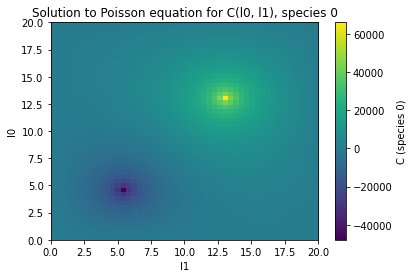

In [8]:
import numpy as np
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt

# 1. Define the grid
n_points = 50
l0_min, l0_max = 0.0, 20.0
l1_min, l1_max = 0.0, 20.0
l0 = np.linspace(l0_min, l0_max, n_points)
l1 = np.linspace(l1_min, l1_max, n_points)
N0, N1 = n_points, n_points
L0, L1 = np.meshgrid(l0, l1, indexing='ij')

# 2. Evaluate Laplacian at each grid point for all species
n_species = len(C0_reduced_initial)
lap_grid = np.zeros((n_species, N0, N1))
for i in range(N0):
    for j in range(N1):
        const_vals = [l0[i], l1[j]]
        
        lap = sim.dC_dl_laplacian_func(
            C0_reduced_initial, const_vals, rates,
            dR_dC_func, dR_dl_func, dR_dl_dl_func, dR_dC_dl_func
        )
        lap_grid[:, i, j] = lap  # shape: (n_species,)

# 3. Poisson solver with C=0 only at the origin
def poisson_2d_origin_only(rhs, dx, dy):
    """
    Solve Δu = rhs on a 2D grid with Dirichlet BC only at the origin (0,0).
    All other points are free (Neumann-like).
    """
    N, M = rhs.shape
    A = lil_matrix((N*M, N*M))
    b = rhs.flatten()

    def idx(i, j):
        return i * M + j

    for i in range(N):
        for j in range(M):
            k = idx(i, j)
            if i == 0 and j == 0:
                # Enforce u=0 at the origin
                A[k, :] = 0
                A[k, k] = 1
                b[k] = 0
            else:
                # Standard 5-point stencil
                A[k, k] = -2.0 / dx**2 - 2.0 / dy**2
                if i > 0:
                    A[k, idx(i-1, j)] = 1.0 / dx**2
                if i < N-1:
                    A[k, idx(i+1, j)] = 1.0 / dx**2
                if j > 0:
                    A[k, idx(i, j-1)] = 1.0 / dy**2
                if j < M-1:
                    A[k, idx(i, j+1)] = 1.0 / dy**2
    u = spsolve(A.tocsr(), b)
    return u.reshape((N, M))

dx = (l0_max - l0_min) / (n_points - 1)
dy = (l1_max - l1_min) / (n_points - 1)

# 4. Solve for all species
C_grid = np.zeros_like(lap_grid)
for s in range(n_species):
    C_grid[s] = poisson_2d_origin_only(lap_grid[s], dx, dy)

# 5. Plot for the first species
plt.imshow(C_grid[0], extent=(l1_min, l1_max, l0_min, l0_max), origin='lower', aspect='auto')
plt.colorbar(label='C (species 0)')
plt.xlabel('l1')
plt.ylabel('l0')
plt.title('Solution to Poisson equation for C(l0, l1), species 0')
plt.show()

In [150]:
# # C_full = (1e0 / sum(L[0])) * np.ones_like(C_full)

# # const_vals_init, C0_reduced = sim.get_const_and_reduced_init(C_full)
# # sim.make_reduced_rhs_with_conservation(const_vals_init)

# # # 4. Integrate the reduced system
# # t_span = (0, 1000)
# # num_points = 20000  
# # r_tol = 1e-6
# # a_tol = 1e-6
# # sol_reduced, C_reduced_init = sim.integrate(sim.reduced_ode_rhs, C0_reduced, t_span=t_span, num_points=num_points, method='Radau', rtol=r_tol, atol=a_tol)

# # const_vals = const_vals_init
# # C0_reduced = C_reduced_init
# # print(C0_reduced)

# const_vals = np.ones(len(r_n.L)) * 1e0
# C0_reduced = np.ones(n_species - len(sim.elimination_solutions)) * 1e0 / sum(L[0])


# l = 0
# l_final = 2
# dl_min = 0.001
# dl_max = 1
# tol = 1e-4
# time_start = time.time()

# norm_list = []
# while l < l_final:
#     args = list(C0_reduced) + list(const_vals) + list(rates)
#     dR_dC_eval = dR_dC_func(*args)
#     dR_dl_eval = dR_dl_func(*args)
#     dC_dl = -np.dot(np.linalg.inv(dR_dC_eval), dR_dl_eval).reshape(-1)
#     norm = np.linalg.norm(dC_dl)
#     norm_list.append(norm)
    
#     # Adjust step size based on norm
#     dl = min(dl_max, max(dl_min, tol/norm))
    
#     # Make sure we don't overshoot l_final
#     dl = min(dl, l_final - l)
    
#     C0_reduced = C0_reduced + dC_dl * dl
#     const_vals = const_vals + dl
#     l += dl
    
# print(C0_reduced)
# C_full = sim.recover_eliminated_species(const_vals, C0_reduced)
# print(C_full)
# print(np.dot(L[0], C_full))
# print(time.time() - time_start)

In [43]:
display(dR_dC)

Matrix([
[-D*k_1 - D*k_2 - 2*k_0*(-D - E - F + const0) + k_4*(8*B - 4*D - 4*E - 4*F + 4*G + 4*const0 - 4*const1) - k_5,     -B*k_1 - B*k_2 - G*k_3 + k_0*(-D - E - F + const0) - k_0*(-2*B + D + E + F - G - const0 + const1) + k_4*(-4*B + 2*D + 2*E + 2*F - 2*G - 2*const0 + 2*const1), -G*k_3 + k_0*(-D - E - F + const0) - k_0*(-2*B + D + E + F - G - const0 + const1) + k_4*(-4*B + 2*D + 2*E + 2*F - 2*G - 2*const0 + 2*const1), -G*k_3 + k_0*(-D - E - F + const0) - k_0*(-2*B + D + E + F - G - const0 + const1) + k_4*(-4*B + 2*D + 2*E + 2*F - 2*G - 2*const0 + 2*const1), -k_0*(-D - E - F + const0) + k_3*(-D - E - F + const0) + k_4*(4*B - 2*D - 2*E - 2*F + 2*G + 2*const0 - 2*const1)],
[                                                      -D*k_1 - D*k_2 + 2*D*k_9 - 2*k_0*(-D - E - F + const0), -B*k_1 - B*k_2 - D*k_9 - E*k_6 - G*k_3 + k_0*(-D - E - F + const0) - k_0*(-2*B + D + E + F - G - const0 + const1) - k_9*(-2*B + D + E + F - G - const0 + const1),                                    -D*k_6 - D*

In [8]:
rates

array([6.10957199e+10, 9.94555098e-04, 1.15978611e+14, 1.18079123e+33,
       8.23045931e-06, 8.23721837e-06, 1.95961419e+34, 4.61990882e+16,
       6.38988791e-11, 6.04702343e+11, 8.64993133e-11, 7.70560776e-11])

[1.47663849e+00 4.52377934e+02 1.46292900e+00 7.45179417e-03
 8.50066735e+00 2.89518575e-02 2.30456481e+00]
[1.47663849e+00 4.52377934e+02 1.46292900e+00 7.45179417e-03
 8.50066735e+00 2.89518575e-02 2.30456481e+00]
[ 10. 910.]


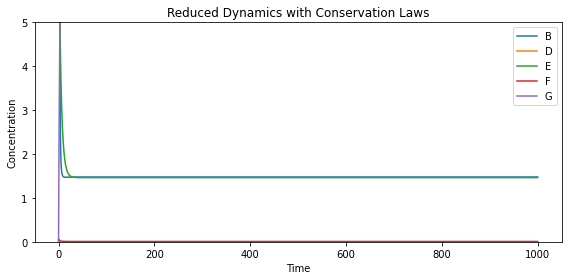

In [12]:
# 3. Generate initial conditions and map to reduced system
C_full = generate_positive_initial_concentrations_nnls(L, l_target + l_base)


const_vals, C0_reduced = sim.get_const_and_reduced_init(C_full)
sim.make_reduced_rhs_with_conservation(const_vals)

# 4. Integrate the reduced system
t_span = (0, 1000)
num_points = 20000  
r_tol = 1e-8
a_tol = 1e-8
sol_full, C_full_final = sim.integrate(sim.rhs, C_full, t_span=t_span, num_points=num_points, method='Radau', rtol=r_tol, atol=a_tol)
sol_reduced, C_reduced_final = sim.integrate(sim.reduced_ode_rhs, C0_reduced, t_span=t_span, num_points=num_points, method='Radau', rtol=r_tol, atol=a_tol)

# 5. Recover eliminated species at final time
C_full_final_recovered = sim.recover_eliminated_species(const_vals, sol_reduced.y[:,-1])
print(sol_full.y[:,-1])
print(C_full_final_recovered)
print(np.dot(L, C_full_final))

# 6. Plot results for remaining species
plt.figure(figsize=(8, 4))
for i, name in enumerate(sim.remaining_species):
    plt.plot(sol_full.t, sol_full.y[i], label=name)
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.legend()
plt.ylim(0, 5)
plt.title('Reduced Dynamics with Conservation Laws')
plt.tight_layout()
plt.show()

In [6]:
def generate_positive_initial_concentrations_nnls(L, const_vals, min_conc=1e-8):
    n_species = L.shape[1]
    # Start from the NNLS solution as an initial guess
    from scipy.optimize import nnls
    C0, _ = nnls(L, const_vals)
    C0 = np.maximum(C0, min_conc)

    def variance(C):
        return np.var(C)

    constraints = [
        {'type': 'eq', 'fun': lambda C: L @ C - const_vals},
        {'type': 'ineq', 'fun': lambda C: C - min_conc}
    ]

    result = minimize(
        variance,
        C0,
        constraints=constraints,
        method='SLSQP',
        options={'ftol': 1e-6, 'maxiter': 5000}
    )

    if not result.success:
        raise RuntimeError("Optimization failed: " + result.message)
    return result.x

In [36]:
l01_range = np.logspace(0, 3, 10)  # Log range from 10^0=1 to 10^2=100
l02_range = np.logspace(0, 3, 10)  # Log range from 10^0=1 to 10^2=100
C_mesh = np.zeros((len(l01_range), len(l02_range), n_species))

t_span = (0, 1000)
num_points = 20000  
r_tol = 1e-6
a_tol = 1e-6
st_val = 1e-2

#rates = np.random.lognormal(mean=0, sigma=1, size=2*n_reactions)

for i, l01 in enumerate(l01_range):
    for j, l02 in enumerate(l02_range):
        l_target = np.array([l01, l02])
        l_norm = np.linalg.norm(l_target)

        # C_full = generate_positive_initial_concentrations_nnls(L, l_target) 
        # const_vals, C0_reduced_initial = sim.get_const_and_reduced_init(C_full)
        # sim.make_reduced_rhs_with_conservation(const_vals)
        # sol_reduced, C_reduced_final = sim.integrate(sim.reduced_ode_rhs, C0_reduced_initial, t_span=t_span, num_points=num_points, method='LSODA', rtol=r_tol, atol=a_tol)
        # C_full_final_recovered = sim.recover_eliminated_species(l_target, sol_reduced.y[:,-1])

        C_full = generate_positive_initial_concentrations_nnls(L, l_target) * st_val
        _, C0_reduced_initial = sim.get_const_and_reduced_init(C_full)
        ode_func = partial(dC_dl_func, rates=rates, l_unit_vec= l_target/l_norm)
        sol = solve_ivp(
            ode_func,
            t_span=(st_val, l_norm),
            y0=C0_reduced_initial,
            method='LSODA',  # or 'LSODA'
            rtol=1e-3,
            atol=1e-3
        )
        C_full_final_recovered = sim.recover_eliminated_species(l_target, sol.y[:, -1])

        C_mesh[i, j, :] = C_full_final_recovered


ValueError: could not broadcast input array from shape (7,) into shape (5,)

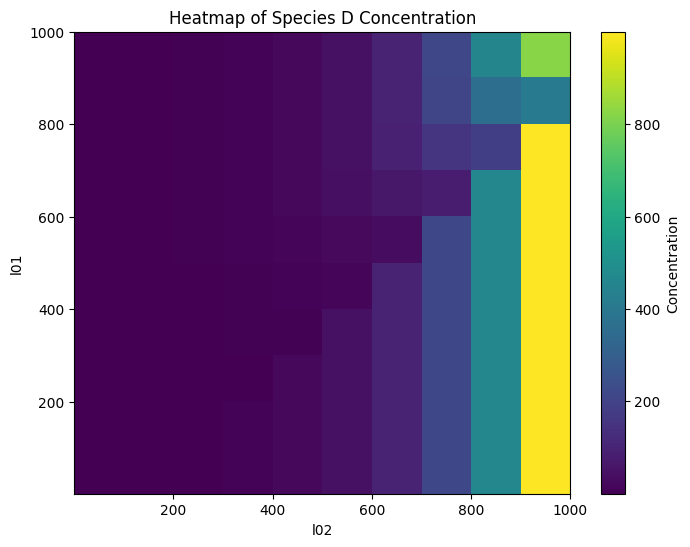

In [201]:
plt.figure(figsize=(8,6))
plt.imshow(C_mesh[:,:,2], extent=[l02_range[0], l02_range[-1], l01_range[0], l01_range[-1]], 
           aspect='auto', origin='lower')
plt.colorbar(label='Concentration')
plt.xlabel('l02')
plt.ylabel('l01') 
plt.title('Heatmap of Species D Concentration')
plt.show()

In [188]:
l_target

array([1000., 1000.])

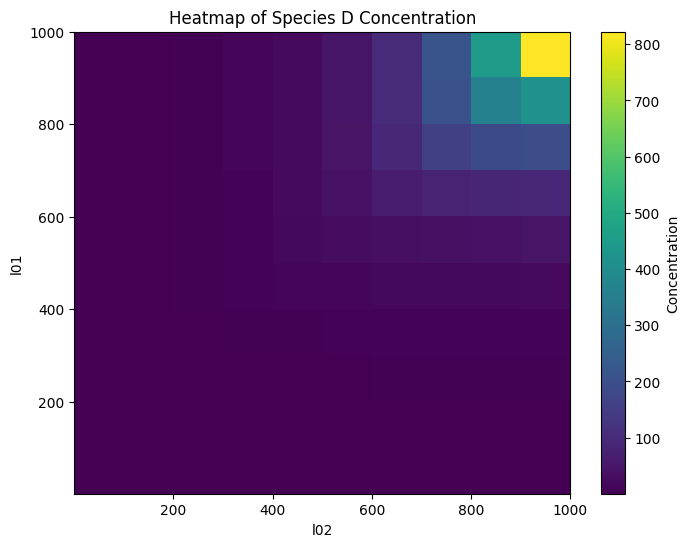

In [197]:
plt.figure(figsize=(8,6))
plt.imshow(C_mesh[:,:,2], extent=[l02_range[0], l02_range[-1], l01_range[0], l01_range[-1]], 
           aspect='auto', origin='lower')
plt.colorbar(label='Concentration')
plt.xlabel('l02')
plt.ylabel('l01') 
plt.title('Heatmap of Species D Concentration')
plt.show()

[9.46038961e+00 1.47102168e-08 1.03743067e-07 5.39610261e-01
 8.05396104e+01 2.33442634e-10 1.44024346e-08]
[9.46038960e+00 1.57768366e-08 1.11247410e-07 5.39610260e-01
 8.05396104e+01 2.50387322e-10 1.54446030e-08]
[100.  10.]


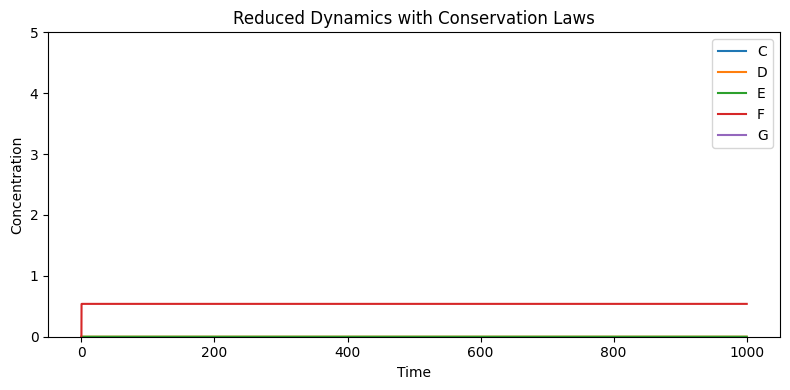

In [63]:
# 3. Generate initial conditions and map to reduced system
C_full = generate_positive_initial_concentrations_nnls(L, l_target)



const_vals, C0_reduced = sim.get_const_and_reduced_init(C_full)
sim.make_reduced_rhs_with_conservation(const_vals)

# 4. Integrate the reduced system
t_span = (0, 1000)
num_points = 20000  
r_tol = 1e-8
a_tol = 1e-8
sol_full, C_full_final = sim.integrate(sim.rhs, C_full, t_span=t_span, num_points=num_points, method='Radau', rtol=r_tol, atol=a_tol)
sol_reduced, C_reduced_final = sim.integrate(sim.reduced_ode_rhs, C0_reduced, t_span=t_span, num_points=num_points, method='Radau', rtol=r_tol, atol=a_tol)

# 5. Recover eliminated species at final time
C_full_final_recovered = sim.recover_eliminated_species(const_vals, sol_reduced.y[:,-1])
print(sol_full.y[:,-1])
print(C_full_final_recovered)
print(np.dot(L, C_full_final))

# 6. Plot results for remaining species
plt.figure(figsize=(8, 4))
for i, name in enumerate(sim.remaining_species):
    plt.plot(sol_full.t, sol_full.y[i], label=name)
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.legend()
plt.ylim(0, 5)
plt.title('Reduced Dynamics with Conservation Laws')
plt.tight_layout()
plt.show()

In [ ]:


nl = 5
l01_range = np.linspace(0,10,nl)
l02_range = np.linspace(0,10,nl)
sol_mesh = np.zeros((nl, nl, n_species))

num_points = 2000
C0_reduced = np.zeros(len(sim.remaining_species)) 
for i, l01 in enumerate(l01_range):
    for j, l02 in enumerate(l02_range):
        const_vals = [l01, l02]
        sim.make_reduced_rhs_with_conservation(const_vals)
        sol_reduced, C_reduced_final = sim.integrate(sim.reduced_ode_rhs, C0_reduced, t_span=t_span, num_points=num_points, method='Radau', rtol=1e-4, atol=1e-4)
        C_full_final_recovered = sim.recover_eliminated_species(const_vals, sol_reduced.y[:,-1])
        sol_mesh[i, j, :] = C_full_final_recovered



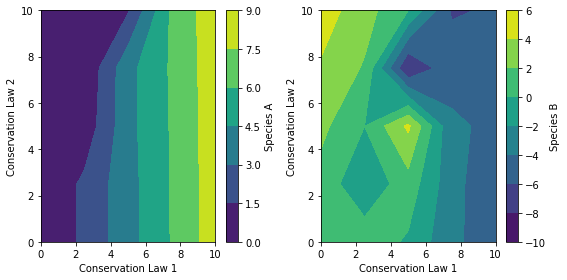

In [14]:
plt.figure(figsize=(8, 4))
plt.subplot(121)
plt.contourf(l01_range, l02_range, sol_mesh[:,:,0].T)
plt.colorbar(label='Species A')
plt.xlabel('Conservation Law 1')
plt.ylabel('Conservation Law 2')

plt.subplot(122) 
plt.contourf(l01_range, l02_range, sol_mesh[:,:,1].T)
plt.colorbar(label='Species B')
plt.xlabel('Conservation Law 1')
plt.ylabel('Conservation Law 2')
plt.tight_layout()


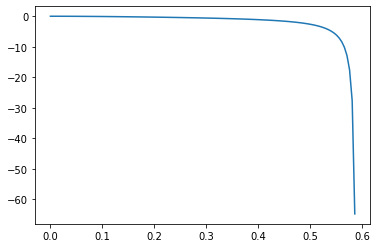

In [10]:
plt.plot(sol_reduced.t, sol_reduced.y[0])

[15 15]
[ 1.33738554e+01  1.61886593e+02 -2.40317376e+04  4.47514501e-01
  2.36945905e+04  1.17863008e+00  1.69968745e+02]


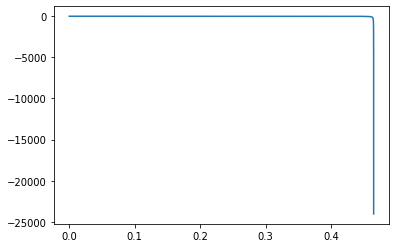

In [34]:
const_vals, C0_reduced = sim.get_const_and_reduced_init(C_full)

const_vals = 3 * np.array([5, 5])
sim.make_reduced_rhs_with_conservation(const_vals)

C0_reduced = np.zeros(len(sim.remaining_species))
t_span = (0, 30)
print(const_vals)
sol_reduced, C_reduced_final = sim.integrate(sim.reduced_ode_rhs, C0_reduced, t_span=t_span, num_points=num_points, method='Radau', rtol=1e-4, atol=1e-4)
C_full_final_recovered = sim.recover_eliminated_species(const_vals, sol_reduced.y[:,-1])
print(C_full_final_recovered)

plt.plot(sol_reduced.t, sol_reduced.y[0])

In [39]:
nl = 20
l01_range = np.linspace(0,10,nl)
l02_range = np.linspace(0,10,nl)
sol_mesh = np.zeros((nl, nl, n_species))

num_points = 2000
C0_reduced = np.zeros(len(sim.remaining_species)) 
for i, l01 in enumerate(l01_range):
    for j, l02 in enumerate(l02_range):
        C_full_init = np.zeros(n_species)
        C_full_init[0] = l01
        C_full_init[2] = l02
        sol_reduced, C_reduced_final = sim.integrate(sim.rhs, C_full_init, t_span=t_span, num_points=num_points, method='Radau', rtol=1e-4, atol=1e-4)
        sol_mesh[i, j, :] = C_reduced_final

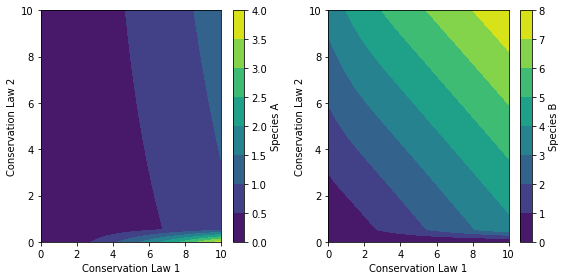

In [40]:
plt.figure(figsize=(8, 4))
plt.subplot(121)
plt.contourf(l01_range, l02_range, sol_mesh[:,:,0].T)
plt.colorbar(label='Species A')
plt.xlabel('Conservation Law 1')
plt.ylabel('Conservation Law 2')

plt.subplot(122) 
plt.contourf(l01_range, l02_range, sol_mesh[:,:,1].T)
plt.colorbar(label='Species B')
plt.xlabel('Conservation Law 1')
plt.ylabel('Conservation Law 2')
plt.tight_layout()